In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os,shutil
import cv2
%matplotlib inline
plt.style.use("ggplot")

In [9]:
#Dataset Extract

In [10]:
import zipfile
import os
zip_path = "/content/drive/MyDrive/Brain Tumor/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)
print("Dataset extracted successfully")
print(os.listdir(extract_path))

Dataset extracted successfully
['Training', 'Testing']


In [11]:
#Dataset Class Count

In [12]:
dataset_path="/content/dataset"
for split in ["Training", "Testing"]:
    split_path = os.path.join(dataset_path, split)
    print("\n" + "=" * 50)
    print(split)
    print("=" * 50)
    for class_name in ["glioma", "meningioma", "notumor", "pituitary"]:
        class_path = os.path.join(split_path, class_name)
        number_files = len(os.listdir(class_path))
        print(class_name, ":", number_files, "images")



Training
glioma : 1400 images
meningioma : 1400 images
notumor : 1400 images
pituitary : 1400 images

Testing
glioma : 400 images
meningioma : 400 images
notumor : 400 images
pituitary : 400 images


In [13]:
#EDA — Exploratory Data Analysis

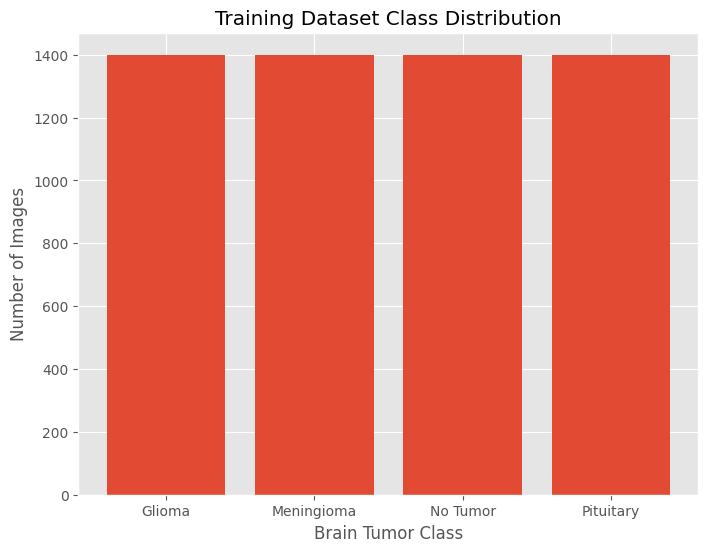

In [14]:

data = {
    "Glioma": 1400,
    "Meningioma": 1400,
    "No Tumor": 1400,
    "Pituitary": 1400
}

typex = data.keys()
values = data.values()

fig = plt.figure(figsize=(8, 6))

plt.bar(typex, values)

plt.xlabel("Brain Tumor Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [16]:
def timing(sec_elapsed):
  h=int(sec_elapsed / (60*60))
  m=int(sec_elapsed % (60*60)/60)
  s=sec_elapsed %60
  return f"{h}:{m}:{s}"

In [17]:
import os

def data_summary(main_path):
    classes = ["glioma", "meningioma", "notumor", "pituitary"]
    total = 0
    for class_name in classes:
        class_path = os.path.join(main_path, class_name)
        count = len(os.listdir(class_path))
        total += count
        percentage = (count * 100) / total if total > 0 else 0
        print(f"{class_name}: {count} images")
    print(f"\nTotal images: {total}")

In [18]:
augmented_data_path = "/content/dataset/Training"
data_summary(augmented_data_path)

glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images

Total images: 5600


In [19]:
# Data Preprocessing

In [20]:
# Convert BGR TO GRAY
# GaussianBlur
# Threshold
# Erode
# Dilate
# Find Contours

In [21]:
import imutils

def crop_brain_tumor(image, plot=False):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    thres = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thres = cv2.erode(thres, None, iterations=2)
    thres = cv2.dilate(thres, None, iterations=2)

    cnts = cv2.findContours(
        thres.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cnts = imutils.grab_contours(cnts)

    if len(cnts) == 0:
        return image

    c = max(cnts, key=cv2.contourArea)

    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    new_image = image[
        extTop[1]:extBot[1],
        extLeft[0]:extRight[0]
    ]

    if plot:
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
        plt.title("Cropped Image")
        plt.axis("off")

        plt.show()

    return new_image

In [22]:
#Sample MRI Images

In [23]:
image_path = "/content/dataset/Training/glioma/" + os.listdir("/content/dataset/Training/glioma/")[0]
image = cv2.imread(image_path)
print("Image path:", image_path)
print("Image shape:", image.shape)

Image path: /content/dataset/Training/glioma/Tr-gl_841.jpg
Image shape: (512, 512, 3)


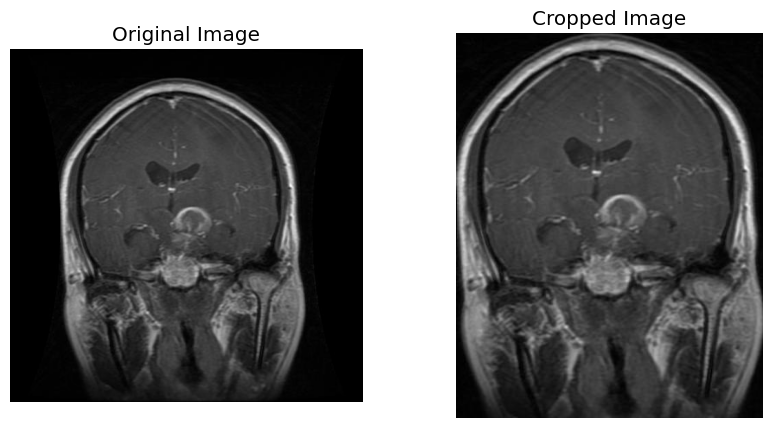

In [24]:
cropped_image = crop_brain_tumor(image, plot=True)

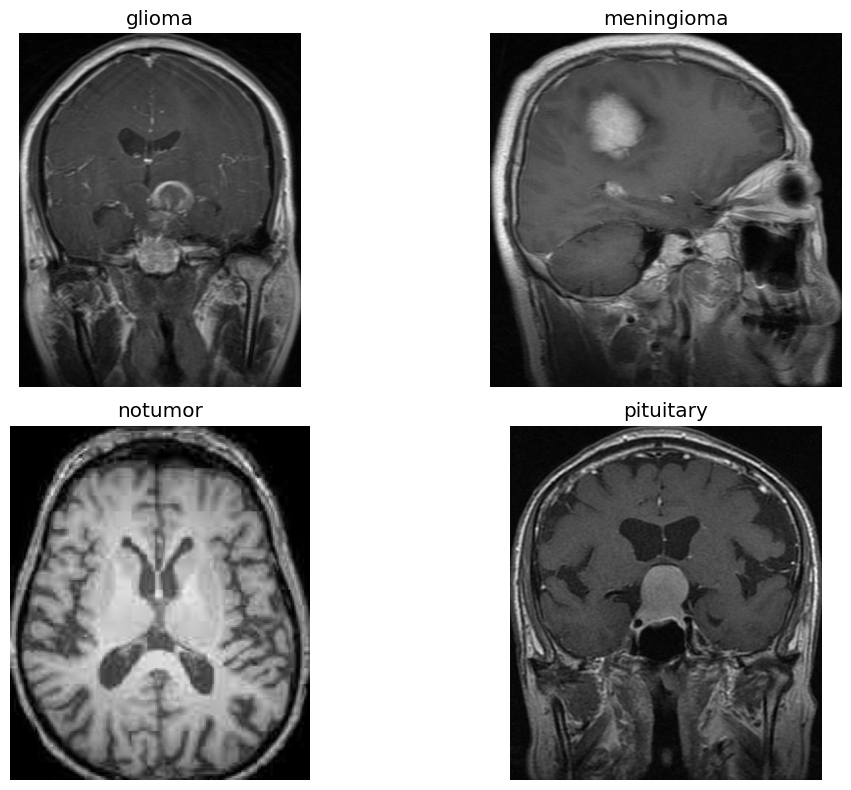

In [25]:
classes = ["glioma", "meningioma", "notumor", "pituitary"]

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = f"/content/dataset/Training/{class_name}"
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)
    cropped = crop_brain_tumor(image)

    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
classes = ["glioma", "meningioma", "notumor", "pituitary"]

for class_name in classes:

    class_path = f"/content/dataset/Training/{class_name}"
    image_files = os.listdir(class_path)[:25]

    plt.figure(figsize=(15, 15))

    for i, image_name in enumerate(image_files):

        image_path = os.path.join(class_path, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(5, 5, i + 1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [27]:
#Image Dimensions Check

In [28]:
# Check image dimensions for all 4 classes

classes = ["glioma", "meningioma", "notumor", "pituitary"]

for class_name in classes:
    class_path = f"/content/dataset/Training/{class_name}"

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)

    print(class_name, ":", image.shape)

glioma : (512, 512, 3)
meningioma : (512, 512, 3)
notumor : (201, 173, 3)
pituitary : (512, 512, 3)


In [29]:
#Image Preprocessing + Augmentation

In [30]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [31]:
#Train / Validation Generator
train_generator = train_datagen.flow_from_directory(
    "/content/dataset/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

#Validation
validation_generator = train_datagen.flow_from_directory(
    "/content/dataset/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

#Testing
test_generator = test_datagen.flow_from_directory(
    "/content/dataset/Testing",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [32]:
print("Class Mapping:")
print(train_generator.class_indices)

Class Mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [33]:
base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("VGG19 model loaded successfully!")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG19 model loaded successfully!


In [34]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

print("Classification layers added successfully!")
model.summary()

Classification layers added successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [35]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [36]:
#Callbacks

In [37]:
checkpoint = ModelCheckpoint(
    "best_brain_tumor_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [38]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_generator = val_datagen.flow_from_directory(
    "/content/dataset/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 1120 images belonging to 4 classes.


In [39]:
#Compile Model 01

In [40]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [41]:
#Train Model 01

In [42]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.2817 - loss: 1.5542
Epoch 1: val_accuracy improved from None to 0.62411, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 92s 533ms/step - accuracy: 0.3098 - loss: 1.4364 - val_accuracy: 0.6241 - val_loss: 1.1911 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.4447 - loss: 1.2331
Epoch 2: val_accuracy improved from 0.62411 to 0.63750, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 545ms/step - accuracy: 0.4721 - loss: 1.1913 - val_accuracy: 0.6375 - val_loss: 1.0492 - learning_rate: 1.0000e-04
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.5475 - loss: 1.0894
Epoch 3: val_accuracy improved from 0.63750 to 0.68125, saving model to best_brain_tumor_model.keras

Epoch 3: fi

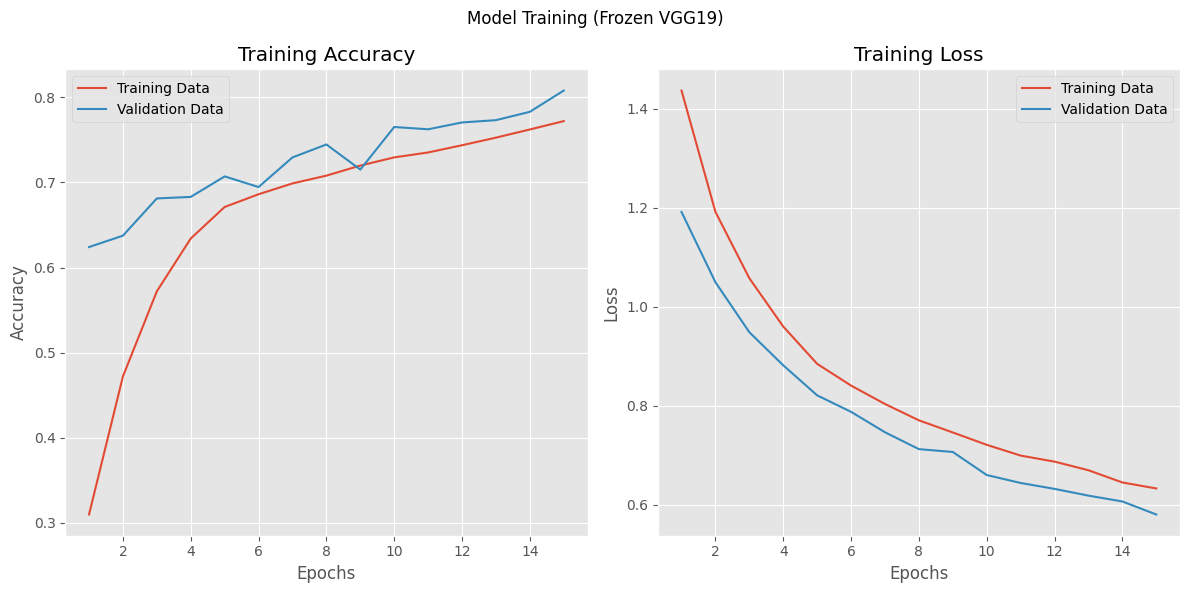

<Figure size 640x480 with 0 Axes>

In [43]:
# Plot performance

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

fig.suptitle("Model Training (Frozen VGG19)", fontsize=12)

max_epoch = len(history.history["accuracy"]) + 1
epochs_list = list(range(1, max_epoch))

# Accuracy
ax1.plot(
    epochs_list,
    history.history["accuracy"],
    linestyle="-",
    label="Training Data"
)

ax1.plot(
    epochs_list,
    history.history["val_accuracy"],
    linestyle="-",
    label="Validation Data"
)

ax1.set_title("Training Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()

# Loss
ax2.plot(
    epochs_list,
    history.history["loss"],
    linestyle="-",
    label="Training Data"
)

ax2.plot(
    epochs_list,
    history.history["val_loss"],
    linestyle="-",
    label="Validation Data"
)

ax2.set_title("Training Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

plt.savefig(
    "training_frozen_vgg19.jpeg",
    format="jpeg",
    dpi=100,
    bbox_inches="tight"
)

In [44]:
#Weights Save

In [45]:
if not os.path.isdir("model_weights"):
    os.mkdir("model_weights")

model.save_weights("model_weights/vgg19_brain_tumor.weights.h5")

In [46]:
best_model = tf.keras.models.load_model("best_brain_tumor_model.keras")

vgg_val_eval = best_model.evaluate(validation_generator)
vgg_test_eval = best_model.evaluate(test_generator)

print("Validation Loss:", vgg_val_eval[0])
print("Validation Accuracy:", vgg_val_eval[1])

print("Test Loss:", vgg_test_eval[0])
print("Test Accuracy:", vgg_test_eval[1])

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.8080 - loss: 0.5800
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 0.7444 - loss: 0.7841
Validation Loss: 0.5800473690032959
Validation Accuracy: 0.8080357313156128
Test Loss: 0.7840672135353088
Test Accuracy: 0.7443749904632568


In [47]:
print(f"Validation Loss: {vgg_val_eval[0]}")
print(f"Validation Accuracy: {vgg_val_eval[1]}")

print(f"Testing Loss: {vgg_test_eval[0]}")
print(f"Testing Accuracy: {vgg_test_eval[1]}")

Validation Loss: 0.5800473690032959
Validation Accuracy: 0.8080357313156128
Testing Loss: 0.7840672135353088
Testing Accuracy: 0.7443749904632568


In [48]:
filenames = test_generator.filenames
nb_sample = len(filenames)

test_generator.reset()

vgg_prediction = best_model.predict(
    test_generator,
    steps=len(test_generator),
    verbose=1
)

y_pred = np.argmax(vgg_prediction, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 227ms/step


In [49]:
base_model_layer_names = [layer.name for layer in base_model.layers]

base_model_layer_names


['input_layer',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_conv4',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_conv4',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_conv4',
 'block5_pool']

In [50]:
# Fine-tuning VGG19

base_model.trainable = True

# Freeze all layers except last 5 layers
for layer in base_model.layers[:-5]:
    layer.trainable = False

for layer in base_model.layers[-5:]:
    layer.trainable = True

print("Fine-tuning layers configured successfully!")

Fine-tuning layers configured successfully!


In [51]:
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name, "-> Trainable")

block5_conv1 -> Trainable
block5_conv2 -> Trainable
block5_conv3 -> Trainable
block5_conv4 -> Trainable
block5_pool -> Trainable


In [52]:
# Incremental Unfreezing and Fine-Tuning

base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_layer_names = [layer.name for layer in base_model.layers]

base_model_layer_names


x = base_model.output

x = GlobalAveragePooling2D()(x)

class_1 = Dense(256, activation="relu")(x)

drop_out = Dropout(0.5)(class_1)

output = Dense(4, activation="softmax")(drop_out)


model_02 = Model(base_model.inputs, output)


# Load weights from the current trained model
model_02.set_weights(model.get_weights())


set_trainable = False

for layer in base_model.layers:

    if layer.name in ["block5_conv3", "block5_conv4"]:
        set_trainable = True

    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False


print(model_02.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 4,851,972 (18.51 MB)

 Non-trainable params: 15,304,768 (58.38 MB)

None


In [53]:
sgd = SGD(
    learning_rate=0.0001,
    momentum=0.9,
    nesterov=True
)

model_02.compile(
    loss="categorical_crossentropy",
    optimizer=sgd,
    metrics=["accuracy"]
)

print("Model compiled for fine-tuning!")

Model compiled for fine-tuning!


In [54]:
history_02 = model_02.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.7783 - loss: 0.5931
Epoch 1: val_accuracy did not improve from 0.80804
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 540ms/step - accuracy: 0.7846 - loss: 0.5814 - val_accuracy: 0.8009 - val_loss: 0.5366 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7875 - loss: 0.5437
Epoch 2: val_accuracy improved from 0.80804 to 0.81607, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 539ms/step - accuracy: 0.8060 - loss: 0.5142 - val_accuracy: 0.8161 - val_loss: 0.5231 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8275 - loss: 0.4791
Epoch 3: val_accuracy improved from 0.81607 to 0.84732, saving model to best_brain_tumor_model.keras

Epoch 3: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 538ms/step - accuracy: 0.8

In [55]:
best_model = tf.keras.models.load_model("best_brain_tumor_model.keras")

test_loss, test_accuracy = best_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - accuracy: 0.8263 - loss: 0.6236
Test Loss: 0.6235833764076233
Test Accuracy: 0.8262500166893005


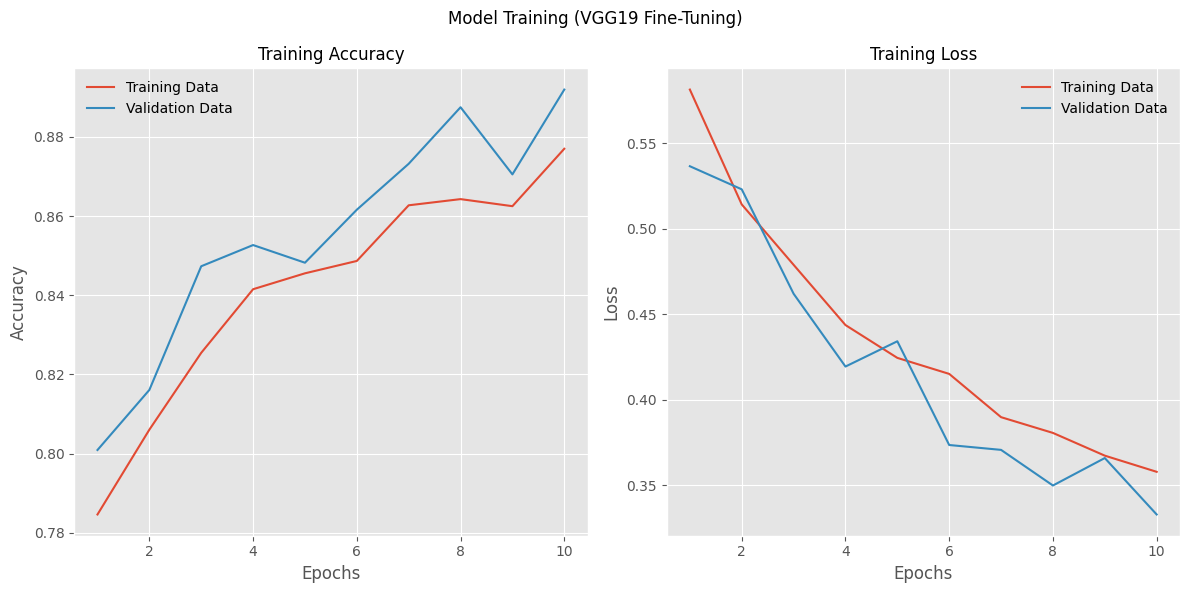

In [56]:
# Plot Fine-Tuning Performance

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

fig.suptitle("Model Training (VGG19 Fine-Tuning)", fontsize=12)

max_epoch = len(history_02.history["accuracy"]) + 1
epochs_list = list(range(1, max_epoch))


# Accuracy Graph
ax1.plot(
    epochs_list,
    history_02.history["accuracy"],
    linestyle="-",
    label="Training Data"
)

ax1.plot(
    epochs_list,
    history_02.history["val_accuracy"],
    linestyle="-",
    label="Validation Data"
)

ax1.set_title("Training Accuracy", fontsize=12)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.legend(frameon=False)


# Loss Graph
ax2.plot(
    epochs_list,
    history_02.history["loss"],
    linestyle="-",
    label="Training Data"
)

ax2.plot(
    epochs_list,
    history_02.history["val_loss"],
    linestyle="-",
    label="Validation Data"
)

ax2.set_title("Training Loss", fontsize=12)
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.legend(frameon=False)


plt.tight_layout()

plt.savefig(
    "training_finetuning_vgg19.jpeg",
    format="jpeg",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

In [57]:
if not os.path.isdir("model_weights"):
    os.mkdir("model_weights")

model_02.save_weights(
    "model_weights/vgg19_model_02.weights.h5"
)

print("Model weights saved successfully!")

Model weights saved successfully!


In [58]:
model_02.load_weights("model_weights/vgg19_model_02.weights.h5")

vgg_val_eval_02 = model_02.evaluate(validation_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print("Validation Loss:", vgg_val_eval_02[0])
print("Validation Accuracy:", vgg_val_eval_02[1])

print("Test Loss:", vgg_test_eval_02[0])
print("Test Accuracy:", vgg_test_eval_02[1])

35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 231ms/step - accuracy: 0.8920 - loss: 0.3328
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.8263 - loss: 0.6236
Validation Loss: 0.3327845633029938
Validation Accuracy: 0.8919642567634583
Test Loss: 0.6235833764076233
Test Accuracy: 0.8262500166893005


In [59]:
# Unfreezing the entire network

In [60]:
# Model 03 - Further Fine-Tuning

base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_layer_names = [layer.name for layer in base_model.layers]

base_model_layer_names


x = base_model.output

x = GlobalAveragePooling2D()(x)

class_1 = Dense(256, activation="relu")(x)

drop_out = Dropout(0.5)(class_1)

output = Dense(4, activation="softmax")(drop_out)


model_03 = Model(base_model.inputs, output)


# Load Model 02 weights
model_03.load_weights(
    "model_weights/vgg19_model_02.weights.h5"
)


# Freeze all layers first
set_trainable = False

for layer in base_model.layers:

    if layer.name in ["block5_conv2", "block5_conv3", "block5_conv4"]:
        set_trainable = True

    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False


# Compile
sgd = SGD(
    learning_rate=0.0001,
    momentum=0.9,
    nesterov=True
)

model_03.compile(
    loss="categorical_crossentropy",
    optimizer=sgd,
    metrics=["accuracy"]
)

print(model_03.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 7,211,780 (27.51 MB)

 Non-trainable params: 12,944,960 (49.38 MB)

None


In [61]:
history_03 = model_03.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.8803 - loss: 0.3395
Epoch 1: val_accuracy did not improve from 0.89196
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 553ms/step - accuracy: 0.8734 - loss: 0.3515 - val_accuracy: 0.8893 - val_loss: 0.3153 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8814 - loss: 0.3244
Epoch 2: val_accuracy did not improve from 0.89196
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 543ms/step - accuracy: 0.8824 - loss: 0.3282 - val_accuracy: 0.8902 - val_loss: 0.3145 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8829 - loss: 0.3288
Epoch 3: val_accuracy did not improve from 0.89196
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 546ms/step - accuracy: 0.8902 - loss: 0.3174 - val_accuracy: 0.8884 - val_loss: 0.3105 - learning_rate: 1.0000e-04
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8885 - loss: 0.3084
Epoch 4: val_accuracy improved from 0.89196 to 0.89

In [62]:
# Model 03 Evaluation

test_loss_03, test_accuracy_03 = model_03.evaluate(
    test_generator
)

print("Model 03 Test Loss:", test_loss_03)
print("Model 03 Test Accuracy:", test_accuracy_03)

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 234ms/step - accuracy: 0.8644 - loss: 0.5125
Model 03 Test Loss: 0.5125129222869873
Model 03 Test Accuracy: 0.8643749952316284


In [63]:
# Model 03 Predictions

test_generator.reset()

predictions = model_03.predict(
    test_generator,
    steps=len(test_generator),
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("Prediction completed!")

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step
Prediction completed!


In [64]:
# Classification Report
from sklearn.metrics import classification_report
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.92      0.70      0.80       400
  meningioma       0.79      0.78      0.79       400
     notumor       0.90      0.98      0.94       400
   pituitary       0.86      0.99      0.92       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600



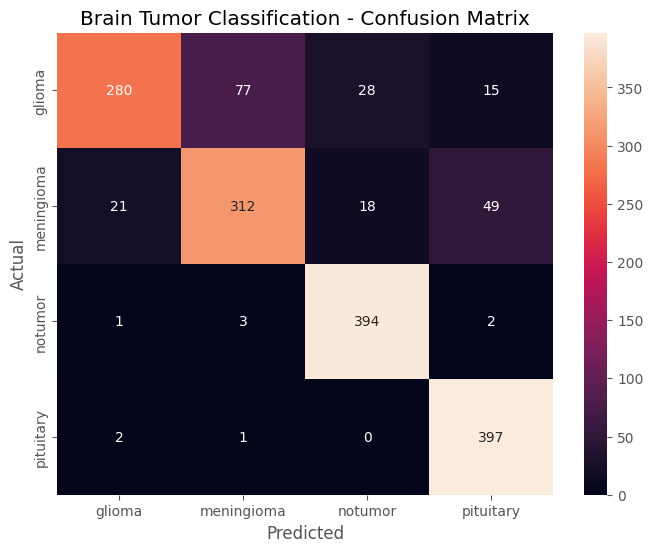

In [65]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Brain Tumor Classification - Confusion Matrix")

plt.show()

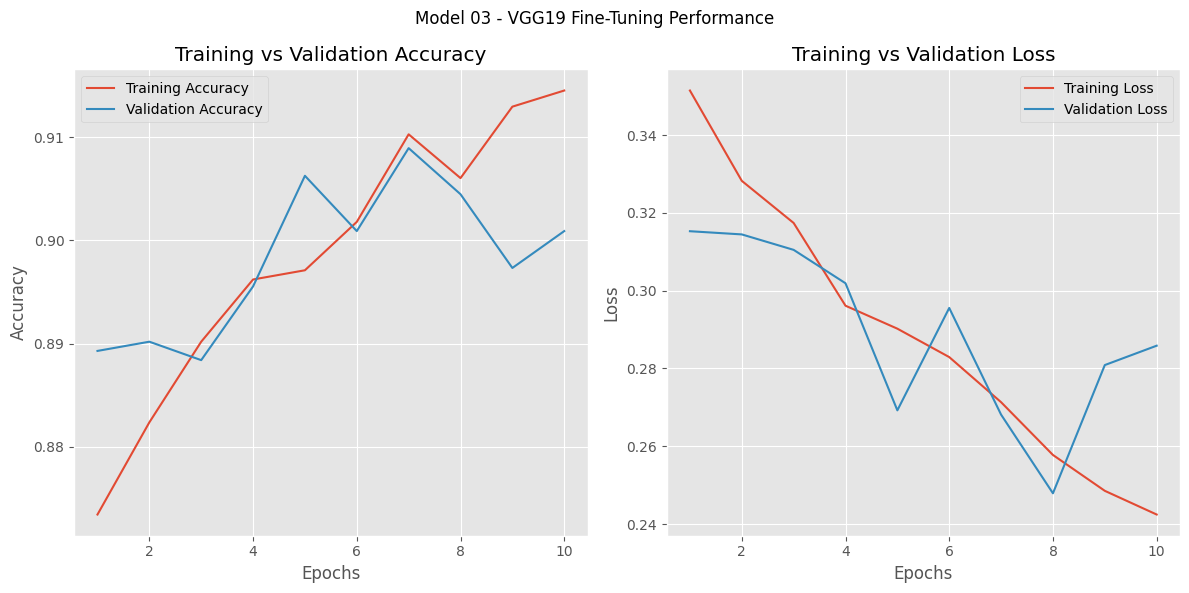

In [66]:
# Model 03 Training Performance

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

fig.suptitle("Model 03 - VGG19 Fine-Tuning Performance")

epochs_list = range(1, len(history_03.history["accuracy"]) + 1)

# Accuracy
ax1.plot(
    epochs_list,
    history_03.history["accuracy"],
    label="Training Accuracy"
)

ax1.plot(
    epochs_list,
    history_03.history["val_accuracy"],
    label="Validation Accuracy"
)

ax1.set_title("Training vs Validation Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()

# Loss
ax2.plot(
    epochs_list,
    history_03.history["loss"],
    label="Training Loss"
)

ax2.plot(
    epochs_list,
    history_03.history["val_loss"],
    label="Validation Loss"
)

ax2.set_title("Training vs Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

In [67]:
# Model 02 vs Model 03 Comparison
# FIX: previously "83.56" was hardcoded instead of using the actual computed
# Model 02 test accuracy (vgg_test_eval_02), which made the comparison wrong.
model_02_test_accuracy = vgg_test_eval_02[1] * 100

print("Model 02 Test Accuracy:", round(model_02_test_accuracy, 2), "%")
print("Model 03 Test Accuracy:", round(test_accuracy_03 * 100, 2), "%")

improvement = (test_accuracy_03 * 100) - model_02_test_accuracy
print("Improvement:", round(improvement, 2), "%")


Model 02 Test Accuracy: 82.63 %
Model 03 Test Accuracy: 86.44 %
Improvement: 3.81 %


In [68]:
# Save Final Model 03

model_03.save("brain_tumor_vgg19_final.keras")

print("Final Model 03 saved successfully!")

Final Model 03 saved successfully!


In [70]:
import cv2
import numpy as np

def is_mri_image(image_path, saturation_threshold=15):
    """
    Heuristic check to confirm whether an image is likely an MRI scan.
    MRI scans are essentially grayscale (very low colour saturation).
    A normal colour photo will have much higher saturation.
    Returns True if the image looks like an MRI, False otherwise.
    """
    image = cv2.imread(image_path)

    if image is None:
        print("\u26a0\ufe0f Warning: Could not read the file. Please upload a valid MRI image.")
        return False

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    avg_saturation = np.mean(hsv[:, :, 1])

    if avg_saturation > saturation_threshold:
        print(f"\u26a0\ufe0f Warning: This does not look like an MRI scan "
              f"(colour content detected, saturation={avg_saturation:.2f}). "
              f"Please upload a valid Brain MRI image.")
        return False

    return True


def generate_mri_report(image_path, trained_model, class_names=None, img_size=None):
    """
    Full pipeline:
      - Rejects the image with a warning if it is not an MRI scan.
      - Otherwise runs the trained model and prints/returns a report.
    """
    if class_names is None:
        class_names = ["glioma", "meningioma", "notumor", "pituitary"]
    if img_size is None:
        img_size = IMG_SIZE  # defined earlier in the notebook (224, 224)

    # Step 1: MRI validation check -> stop with a warning if it fails
    if not is_mri_image(image_path):
        return None

    # Step 2: Preprocess exactly like the training pipeline
    image = cv2.imread(image_path)
    image = cv2.resize(image, img_size)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.astype("float32") / 255.0
    image = np.expand_dims(image, axis=0)

    # Step 3: Predict
    prediction = trained_model.predict(image)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction)) * 100

    print("\u2705 MRI image detected. Generating report...")
    print(f"Predicted Class : {predicted_class}")
    print(f"Confidence      : {confidence:.2f}%")

    return {"class": predicted_class, "confidence": confidence}


In [71]:
# Example usage (uncomment and set your own image path):
# generate_mri_report("/content/dataset/Testing/glioma/<some_image>.jpg", model_03)
#
# Example with a non-MRI (normal photo) -> will print a warning and skip prediction:
# generate_mri_report("/content/sample_data/random_photo.jpg", model_03)


In [73]:
from google.colab import files

files.download("/content/brain_tumor_vgg19_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>